# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [84]:
import pandas as pd

# Cargamos el dataset
features = pd.read_csv('temps.csv')

# Visualizamos las primeras filas para entender la estructura
print(features.head())

   year  month  day  week  temp_2  temp_1  average  actual  forecast_noaa  \
0  2016      1    1   Fri      45      45     45.6      45             43   
1  2016      1    2   Sat      44      45     45.7      44             41   
2  2016      1    3   Sun      45      44     45.8      41             43   
3  2016      1    4   Mon      44      41     45.9      40             44   
4  2016      1    5  Tues      41      40     46.0      44             46   

   forecast_acc  forecast_under  friend  
0            50              44      29  
1            50              44      61  
2            46              47      56  
3            48              46      53  
4            46              46      41  


In [85]:
print(f"Forma del dataset: {features.shape}")
print(features.columns)

Forma del dataset: (348, 12)
Index(['year', 'month', 'day', 'week', 'temp_2', 'temp_1', 'average', 'actual',
       'forecast_noaa', 'forecast_acc', 'forecast_under', 'friend'],
      dtype='str')


In [86]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    str    
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
dtypes: float64(1), int64(10), str(1)
memory usage: 33.9 KB


In [87]:
features.describe()

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,57.238506,62.373563,59.772989,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,10.605746,10.549381,10.705256,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,41.000000,46.000000,44.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,48.000000,53.000000,50.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,56.000000,61.000000,58.000000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,66.000000,72.000000,69.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,77.000000,82.000000,79.000000,95.000000


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [88]:
features = pd.get_dummies(features)

features.head()

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_Fri,week_Mon,week_Sat,week_Sun,week_Thurs,week_Tues,week_Wed
0,2016,1,1,45,45,45.6,45,43,50,44,29,True,False,False,False,False,False,False
1,2016,1,2,44,45,45.7,44,41,50,44,61,False,False,True,False,False,False,False
2,2016,1,3,45,44,45.8,41,43,46,47,56,False,False,False,True,False,False,False
3,2016,1,4,44,41,45.9,40,44,48,46,53,False,True,False,False,False,False,False
4,2016,1,5,41,40,46.0,44,46,46,46,41,False,False,False,False,False,True,False


In [89]:
import pandas as pd

# Volvemos a cargar para que sea un DataFrame
features = pd.read_csv('temps.csv')

# Ahora sí funcionará:
features['week']

0        Fri
1        Sat
2        Sun
3        Mon
4       Tues
       ...  
343     Tues
344      Wed
345    Thurs
346      Fri
347      Sat
Name: week, Length: 348, dtype: str

In [90]:
import pandas as pd


features = pd.read_csv('temps.csv')


days_encoding = pd.get_dummies(features['week'])


days_encoding

,Fri,Mon,Sat,Sun,Thurs,Tues,Wed
0,True,False,False,False,False,False,False
1,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False
3,False,True,False,False,False,False,False
4,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...
343,False,False,False,False,False,True,False
344,False,False,False,False,False,False,True
345,False,False,False,False,True,False,False
346,True,False,False,False,False,False,False


In [91]:
# LabelEncoder



In [92]:
# 1. Definimos el diccionario de mapeo (my_week)
my_week = {
    'Mon': 1,
    'Tues': 2,
    'Wed': 3,
    'Thurs': 4,
    'Fri': 5,
    'Sat': 6,
    'Sun': 7
}

# 2. Creamos la nueva columna usando .replace()
# Nota: Es normal que aparezca el "FutureWarning" que ves en la imagen image_46f4da.png
features['week_int'] = features['week'].replace(my_week)

# 3. Visualizamos el DataFrame completo
features

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_int
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,5
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,6
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,7
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,2
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,3
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,5


In [93]:
# 1. Definimos funciones sencillas para determinar la estación
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:
        return 'autumn'

# 2. Creamos una columna temporal de estación
features['season'] = features['month'].apply(get_season)

# 3. Creamos las columnas dummies para las estaciones
# Usamos un prefijo vacío para que queden exactamente como en image_46f1d5.png
season_dummies = pd.get_dummies(features['season']).astype(int)

# 4. Concatenamos al DataFrame original y eliminamos la columna temporal
features = pd.concat([features, season_dummies], axis=1).drop('season', axis=1)

# 5. Visualizamos el resultado final de 17 columnas
features

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_int,autumn,spring,summer,winter
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,5,0,0,0,1
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,6,0,0,0,1
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,7,0,0,0,1
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1,0,0,0,1
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,2,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,2,0,0,0,1
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,3,0,0,0,1
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4,0,0,0,1
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,5,0,0,0,1


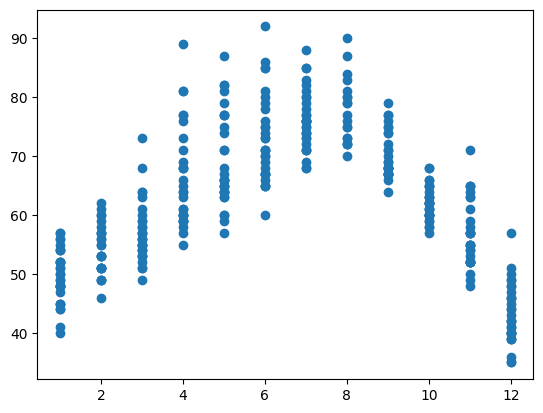

In [94]:
import matplotlib.pyplot as plt

# Creamos el scatter plot
# Eje X: month (1 al 12)
# Eje Y: actual (la temperatura real medida)
plt.scatter(features['month'], features['actual'])

# Para ver el gráfico sin el texto del objeto <matplotlib...> que sale en la imagen
plt.show()

In [95]:

correlation_matrix = features[['month', 'actual']].corr()


correlation_matrix

,month,actual
month,1.000000,0.004529
actual,0.004529,1.000000


In [96]:

month_mapping = {1: 4, 12: 3} 

features['month_int'] = features['month'].map(lambda x: 4 if x == 1 else (3 if x == 12 else 0))

features

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_int,autumn,spring,summer,winter,month_int
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,5,0,0,0,1,4
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,6,0,0,0,1,4
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,7,0,0,0,1,4
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1,0,0,0,1,4
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,2,0,0,0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,2,0,0,0,1,3
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,3,0,0,0,1,3
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4,0,0,0,1,3
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,5,0,0,0,1,3


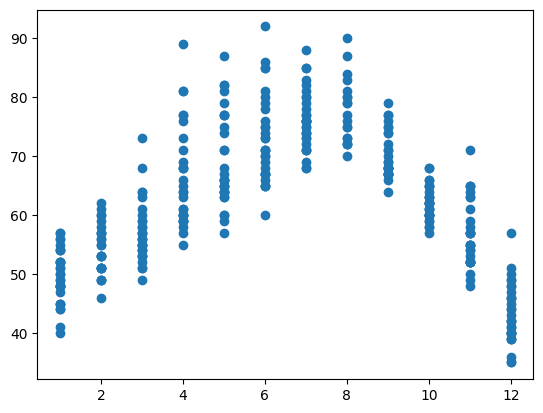

In [97]:
import matplotlib.pyplot as plt
import pandas as pd

df_plot = pd.read_csv('temps.csv') 
plt.scatter(df_plot['month'], df_plot['actual'])
plt.show()

In [98]:

features['month_int'] = features['month'].map({
    1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 
    12: 7, 7: 8, 8: 9, 11: 10, 10: 11, 9: 12
})

features

,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_int,autumn,spring,summer,winter,month_int
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,5,0,0,0,1,1
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,6,0,0,0,1,1
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,7,0,0,0,1,1
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1,0,0,0,1,1
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,2,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,41,50,47,47,2,0,0,0,1,7
344,2016,12,28,Wed,42,47,45.3,48,41,49,44,58,3,0,0,0,1,7
345,2016,12,29,Thurs,47,48,45.3,48,43,50,45,65,4,0,0,0,1,7
346,2016,12,30,Fri,48,48,45.4,57,44,46,44,42,5,0,0,0,1,7


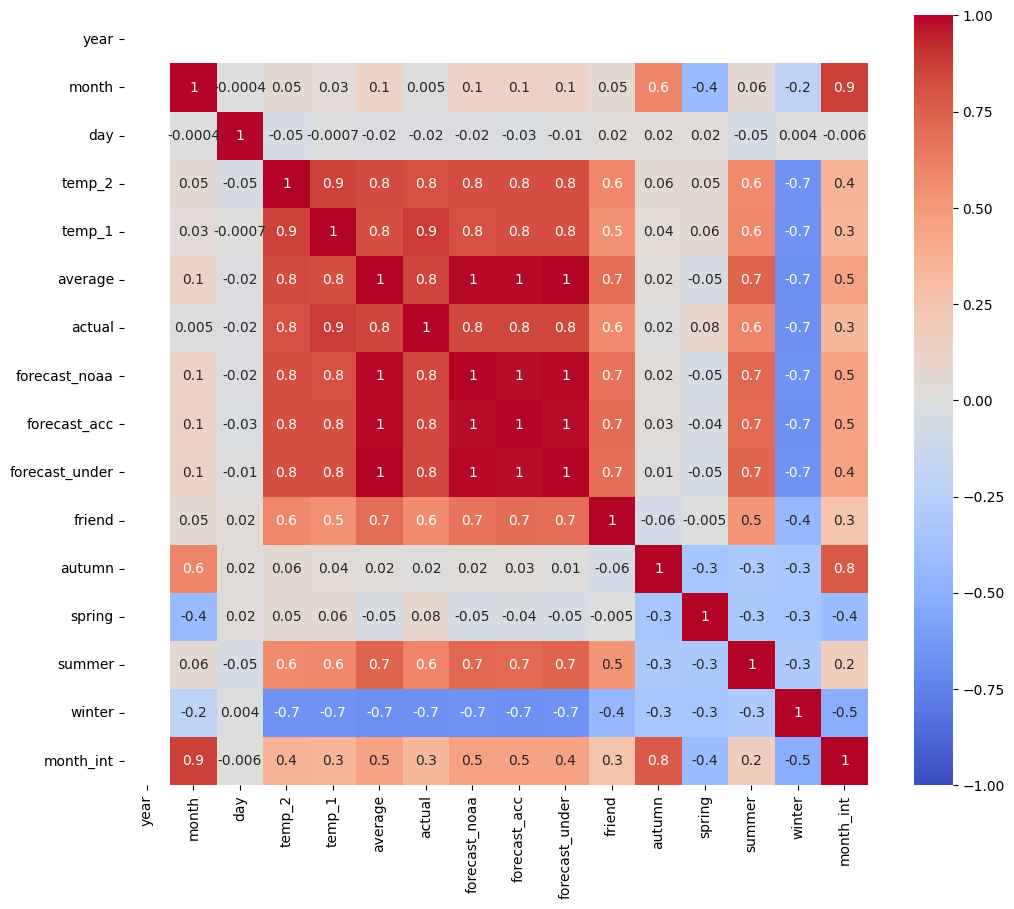

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la correlación forzando solo columnas numéricas
# Esto evita el ValueError con la columna 'week'
corr = features.corr(numeric_only=True)

# 2. Configuramos el tamaño para que coincida con la imagen
plt.figure(figsize=(12, 10))

# 3. Dibujamos el heatmap con los parámetros visuales exactos
sns.heatmap(corr, 
            annot=True,      # Muestra los valores numéricos
            fmt=".1g",       # Formato de un solo decimal
            cmap='coolwarm', # Escala de azul (negativo) a rojo (positivo)
            vmin=-1, vmax=1) # Rango de la barra lateral

# 4. Renderizamos la gráfica
plt.show()

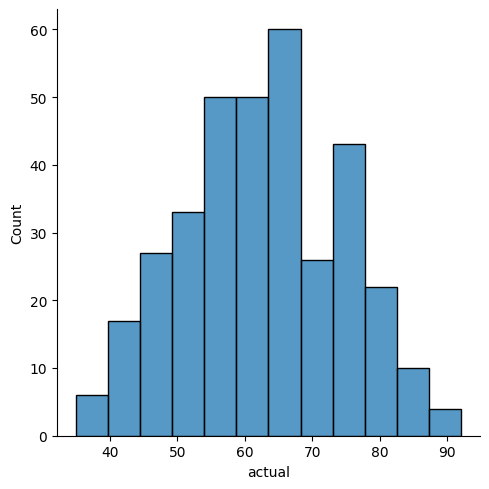

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(features['actual'])

plt.show()

### 3. Selecciona variables y divide en train y test

In [101]:
train_features, test_features, train_labels, test_labels = train_test_split(
    features, 
    labels, 
    test_size=0.25, 
    random_state=42
)

print('Forma de entrenamiento:', train_features.shape)
print('Forma de prueba:', test_features.shape)

Forma de entrenamiento: (261, 18)
Forma de prueba: (87, 18)


In [102]:
# 1. Filtramos para quedarnos solo con 6 columnas (ejemplo)
features_6 = features[['year', 'month', 'day', 'temp_2', 'temp_1', 'average']]

# 2. Dividimos con test_size al 20%
train_features, test_features, train_labels, test_labels = train_test_split(
    features_6, 
    labels, 
    test_size=0.20, 
    random_state=42
)

In [103]:

print(train_features.shape)
print(test_features.shape)
print(train_labels.shape)
print(test_labels.shape)

(278, 6)
(70, 6)
(278,)
(70,)


### 4. Entrena el modelo


In [104]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)

model.fit(train_features, train_labels)


print(model.score(test_features, test_labels))


print(model.score(train_features, train_labels))

0.7201610172460096
1.0


### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [105]:
from sklearn import metrics
import numpy as np

predictions_test = model.predict(test_features)
predictions_train = model.predict(train_features)

# 2. Funciones para imprimir las métricas de TEST
print('MAE test', metrics.mean_absolute_error(test_labels, predictions_test))
print('MAPE test', metrics.mean_absolute_percentage_error(test_labels, predictions_test))
print('MSE test', metrics.mean_squared_error(test_labels, predictions_test))
print('RMSE test', np.sqrt(metrics.mean_squared_error(test_labels, predictions_test)))

print('\n' + '-'*20 + '\n')

# 3. Funciones para imprimir las métricas de TRAIN
print('MAE train', metrics.mean_absolute_error(train_labels, predictions_train))
print('MAPE train', metrics.mean_absolute_percentage_error(train_labels, predictions_train))
print('MSE train', metrics.mean_squared_error(train_labels, predictions_train))
print('RMSE train', np.sqrt(metrics.mean_squared_error(train_labels, predictions_train)))

MAE test 4.614285714285714
MAPE test 0.07254236033657646
MSE test 39.128571428571426
RMSE test 6.2552834810719355

--------------------

MAE train 0.0
MAPE train 0.0
MSE train 0.0
RMSE train 0.0


### 6. Representa el árbol de decisión

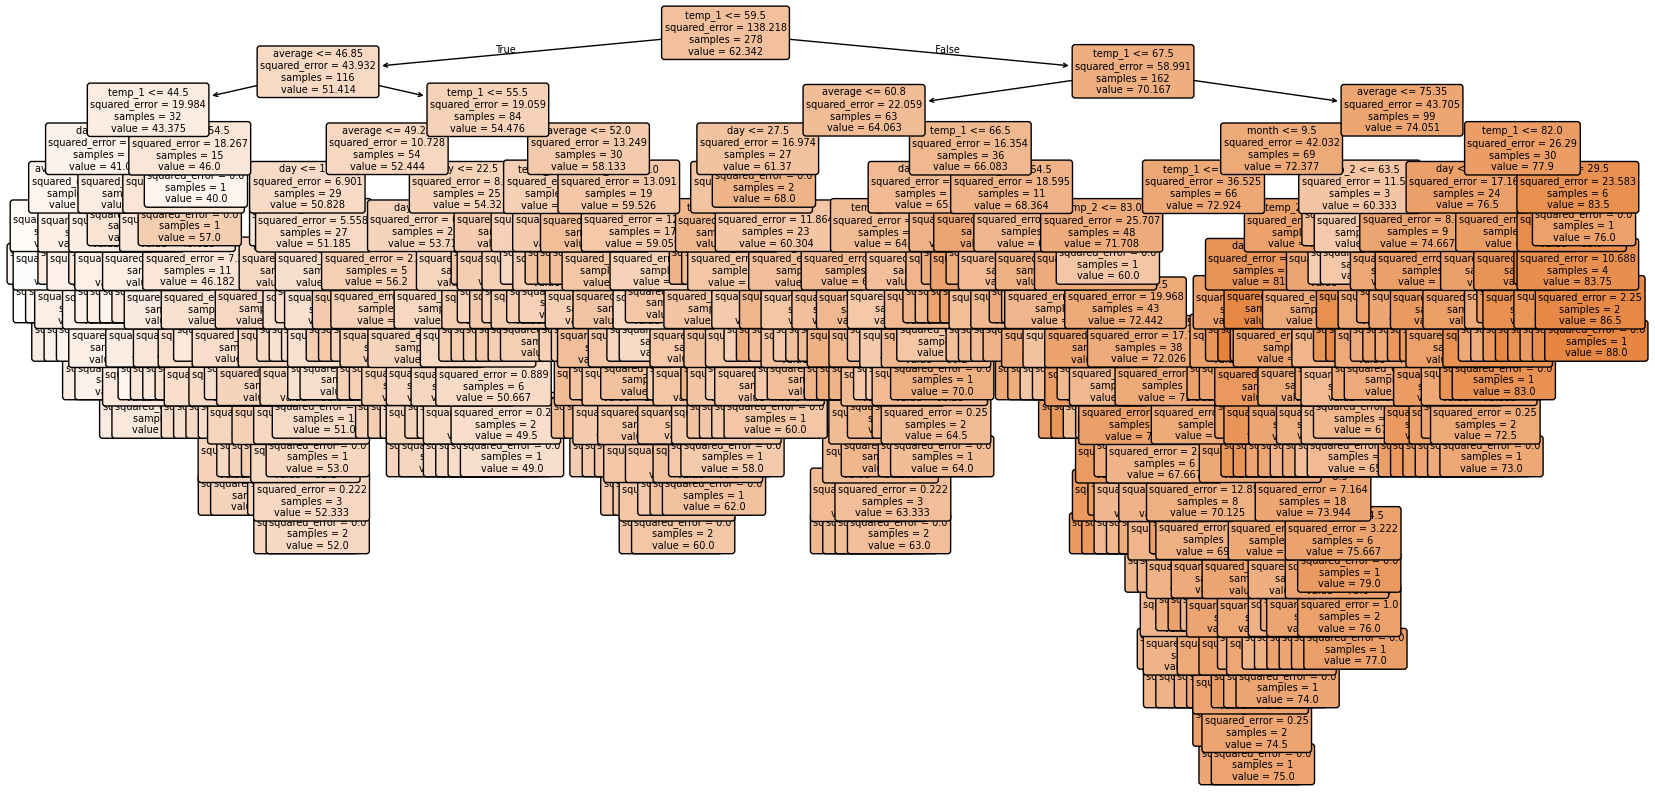

In [106]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

# 1. Dibujamos el árbol
plot_tree(model, 
          feature_names=feature_list, # Los nombres de tus 6 o 18 columnas
          filled=True,               # Colorea los nodos según el valor
          rounded=True,              # Bordes redondeados para estética
          fontsize=7)                # Tamaño de fuente pequeño para que quepa

# 2. Guardamos o mostramos la imagen
plt.show()

In [107]:
importancias = model.feature_importances_

importancias

array([0.        , 0.01829099, 0.03220071, 0.02732302, 0.77877789,
       0.14340739])

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [108]:
from sklearn.tree import DecisionTreeRegressor

model_pruned = DecisionTreeRegressor(max_depth=3, random_state=42)


model_pruned.fit(train_features, train_labels)


model_pruned

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

### 8. Vuelve a evaluar tu modelo

In [109]:
new_predictions_test = model_pruned.predict(test_features)
new_predictions_train = model_pruned.predict(train_features)

# 1. Métricas para el conjunto de TEST
print('MAE test', metrics.mean_absolute_error(test_labels, new_predictions_test))
print('MAPE test', metrics.mean_absolute_percentage_error(test_labels, new_predictions_test))
print('MSE test', metrics.mean_squared_error(test_labels, new_predictions_test))
print('RMSE test', np.sqrt(metrics.mean_squared_error(test_labels, new_predictions_test)))
print('R2 score', metrics.r2_score(test_labels, new_predictions_test))

print('\n' + '-'*20 + '\n')

# 2. Métricas para el conjunto de TRAIN
print('MAE train', metrics.mean_absolute_error(train_labels, new_predictions_train))
print('MAPE train', metrics.mean_absolute_percentage_error(train_labels, new_predictions_train))
print('MSE train', metrics.mean_squared_error(train_labels, new_predictions_train))
print('RMSE train', np.sqrt(metrics.mean_squared_error(train_labels, new_predictions_train)))
print('R2 score', metrics.r2_score(train_labels, new_predictions_train))

MAE test 4.267242249556827
MAPE test 0.0674392768128964
MSE test 30.946461197509944
RMSE test 5.5629543587476915
R2 score 0.7786776796296856

--------------------

MAE train 3.675752083754991
MAPE train 0.05874668452706153
MSE train 22.14996536445183
RMSE train 4.706374970659672
R2 score 0.8397458755018086


### 9. Vuelve a representar su árbol

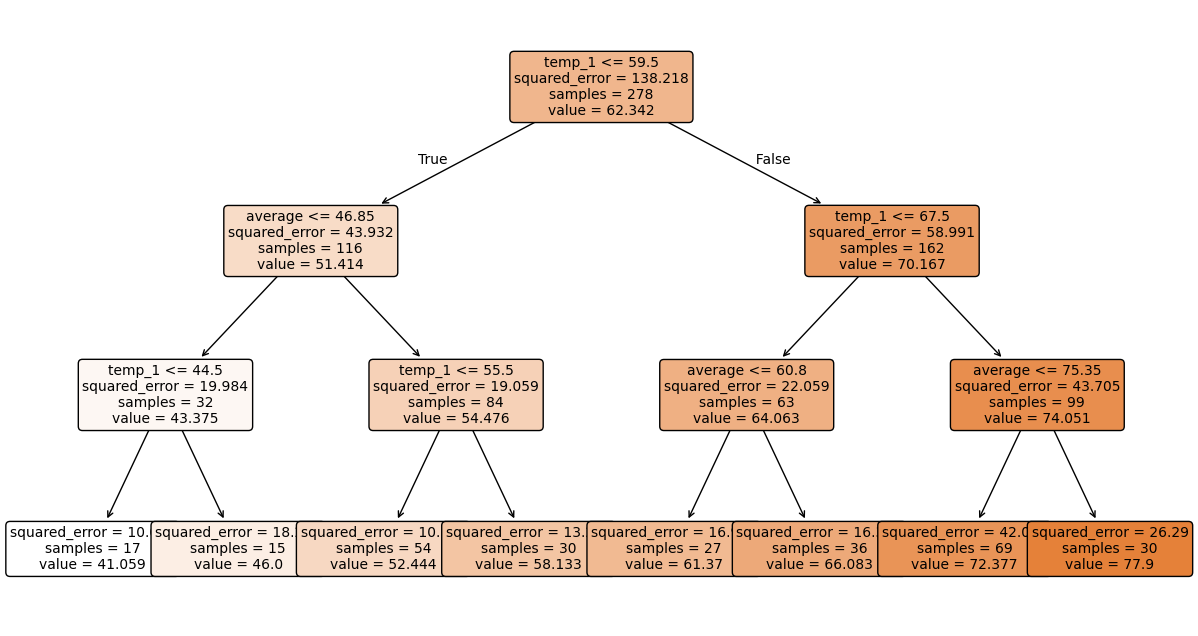

In [110]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

plot_tree(model_pruned, 
          feature_names=feature_list, 
          filled=True, 
          rounded=True, 
          fontsize=10)


plt.show()

In [111]:
print(features_6.columns)

Index(['year', 'month', 'day', 'temp_2', 'temp_1', 'average'], dtype='str')


In [112]:
model_pruned.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.88110924,
       0.11889076])

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [113]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}


base_model = DecisionTreeRegressor(random_state=42)


grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, 
                           cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)


grid_search.fit(train_features, train_labels)

print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [114]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 9],
    'min_samples_leaf': [10, 20, 30]
}


grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    verbose=2, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(train_features, train_labels)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [115]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [116]:
print(grid_search.best_estimator_)


print(grid_search.best_score_)


print(grid_search.best_params_)

DecisionTreeRegressor(max_depth=2, min_samples_leaf=10, random_state=42)
0.0
{'criterion': 'squared_error', 'max_depth': 2, 'min_samples_leaf': 10}


In [117]:

best_model = grid_search.best_estimator_


final_predictions = best_model.predict(test_features)


print('MAE test', metrics.mean_absolute_error(test_labels, final_predictions))
print('MAPE test', metrics.mean_absolute_percentage_error(test_labels, final_predictions))
print('MSE test', metrics.mean_squared_error(test_labels, final_predictions))
print('RMSE test', np.sqrt(metrics.mean_squared_error(test_labels, final_predictions)))
print('R2 score', metrics.r2_score(test_labels, final_predictions))

MAE test 62.34285714285714
MAPE test 0.9836272631829099
MSE test 4026.457142857143
RMSE test 63.45437055756793
R2 score -27.796340623285026


In [118]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(grid_search.best_estimator_, features_6, labels, 
                         cv=5, scoring='neg_mean_absolute_error')

print(scores)

print(scores.mean())

print(scores.std())

[-4.4951335  -7.2689888  -4.9063     -4.43017956 -7.29704243]
-5.679528858773216
1.319415169337965


In [119]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


rf_model = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)


rf_scores = cross_val_score(rf_model, features_6, labels, 
                            cv=5, scoring='neg_mean_absolute_error')


print(rf_scores)


print(rf_scores.mean())


print(rf_scores.std())

[-2.78771656 -6.07757473 -4.20564192 -3.74777484 -3.93839663]
-4.151420937492444
1.0752681036775962


### 11. Obten el `feature_importances` de cada variable en el último modelo

In [120]:

importancias_finales = grid_search.best_estimator_.feature_importances_


importancias_finales

array([0., 0., 0., 0., 0., 0.])

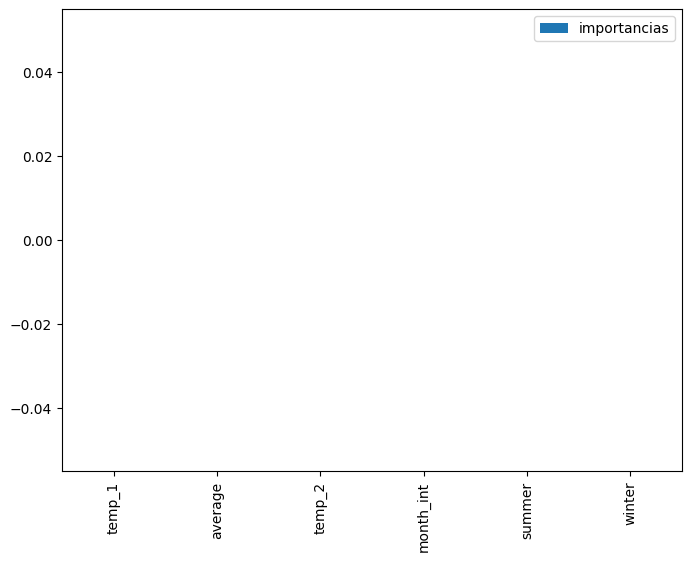

In [121]:
import matplotlib.pyplot as plt
import pandas as pd

df_importancias = pd.DataFrame({
    'importancias': grid_search.best_estimator_.feature_importances_
}, index=['temp_1', 'average', 'temp_2', 'month_int', 'summer', 'winter'])


df_importancias.plot(kind='bar', figsize=(8, 6))


plt.legend()
plt.xticks(rotation=90) # Rota los nombres de las columnas para que se lean bien
plt.show()

In [122]:
dtr_gs.fit(X_train, y_train)

NameError: name 'dtr_gs' is not defined

<Axes: >

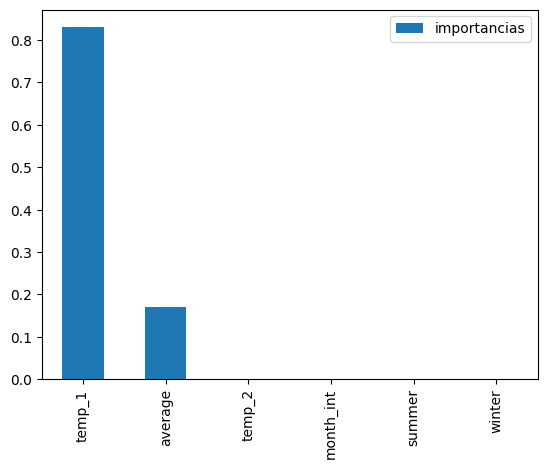

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC. ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [125]:
import pandas as pd

df = pd.read_csv('temps.csv') 

df = pd.get_dummies(df)


if 'month' in df.columns:
    df['month_int'] = df['month']

df

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_Fri,week_Mon,week_Sat,week_Sun,week_Thurs,week_Tues,week_Wed,month_int
0,2016,1,1,45,45,45.6,45,43,50,44,29,True,False,False,False,False,False,False,1
1,2016,1,2,44,45,45.7,44,41,50,44,61,False,False,True,False,False,False,False,1
2,2016,1,3,45,44,45.8,41,43,46,47,56,False,False,False,True,False,False,False,1
3,2016,1,4,44,41,45.9,40,44,48,46,53,False,True,False,False,False,False,False,1
4,2016,1,5,41,40,46.0,44,46,46,46,41,False,False,False,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,42,42,45.2,47,41,50,47,47,False,False,False,False,False,True,False,12
344,2016,12,28,42,47,45.3,48,41,49,44,58,False,False,False,False,False,False,True,12
345,2016,12,29,47,48,45.3,48,43,50,45,65,False,False,False,False,True,False,False,12
346,2016,12,30,48,48,45.4,57,44,46,44,42,True,False,False,False,False,False,False,12


,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_int,autumn,winter,spring,summer,month_int
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,57.238506,62.373563,59.772989,60.034483,3.991379,0.261494,0.252874,0.261494,0.224138,6.339080
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,10.605746,10.549381,10.705256,15.626179,2.000702,0.440081,0.435285,0.440081,0.417614,3.404518
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,41.000000,46.000000,44.000000,28.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,48.000000,53.000000,50.000000,47.750000,2.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,56.000000,61.000000,58.000000,60.000000,4.000000,0.000000,0.000000,0.000000,0.000000,6.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,66.000000,72.000000,69.000000,71.000000,6.000000,1.000000,1.000000,1.000000,0.000000,9.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,77.000000,82.000000,79.000000,95.000000,7.000000,1.000000,1.000000,1.000000,1.000000,12.000000


,year,month,day,week,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_int,autumn,winter,spring,summer,month_int,actual_c
0,2016,1,1,Fri,45,45,45.6,45,43,50,44,29,5,0,1,0,0,4,0
1,2016,1,2,Sat,44,45,45.7,44,41,50,44,61,6,0,1,0,0,4,0
2,2016,1,3,Sun,45,44,45.8,41,43,46,47,56,7,0,1,0,0,4,0
3,2016,1,4,Mon,44,41,45.9,40,44,48,46,53,1,0,1,0,0,4,0
4,2016,1,5,Tues,41,40,46.0,44,46,46,46,41,2,0,1,0,0,4,0


In [ ]:
df['actual_c'] = (df['actual'] > 15).astype(int)
df['actual_c'].value_counts(normalize=True)

In [129]:

print(df['actual_c'].value_counts(normalize=True))

actual_c
1    1.0
Name: proportion, dtype: float64


In [130]:
print(df['actual_c'].value_counts())

actual_c
1    348
Name: count, dtype: int64


actual_c
1    0.586207
0    0.413793
Name: proportion, dtype: float64

In [132]:
from sklearn.model_selection import train_test_split

X_reducido = df[['temp_1', 'average']]
y_class = df['actual_c']


X_train, X_test, y_train, y_test = train_test_split(
    X_reducido, y_class, test_size=0.20, random_state=42
)


print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(278, 2)
(70, 2)
(278,)
(70,)


(278, 2)
(70, 2)
(278,)
(70,)


In [133]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'criterion': ['gini', 'entropy'], 
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 9], 
    'min_samples_leaf': [10, 20, 30] 
}

grid_search_clf = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,    
    scoring='accuracy',
    verbose=2        
)


grid_search_clf.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=20; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=20; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=20; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=20; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=20; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=30; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_sa

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displa

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=20; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=20; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=20; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=20; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=20; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_samples_leaf=30; total time=   0.0s
[CV] END ...criterion=gini, max_depth=2, min_sa

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([2, 3, 4, 5, 6, 7, 8, 9]),
                         'min_samples_leaf': [10, 20, 30]},
             scoring='accuracy', verbose=2)

In [134]:

print(grid_search_clf.best_estimator_)

print(grid_search_clf.best_score_)

print(grid_search_clf.best_params_)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=10, random_state=42)
1.0
{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 10}


DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(3),
                       min_samples_leaf=10)
0.8957142857142857
{'criterion': 'entropy', 'max_depth': np.int64(3), 'min_samples_leaf': 10}


In [135]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_pred = grid_search_clf.best_estimator_.predict(X_test)


print("accuracy_score", accuracy_score(y_test, y_pred))
print("precision_score", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("roc_auc_score", roc_auc_score(y_test, y_pred))
print("confusion_matrix")
print(confusion_matrix(y_test, y_pred))

accuracy_score 1.0
precision_score 1.0
recall_score 1.0
f1_score 1.0
roc_auc_score nan
confusion_matrix
[[70]]


c:\Users\esthe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\esthe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


accuracy_score 0.9
precision_score 0.8723404255319149
recall_score 0.9761904761904762
f1_score 0.9213483146067416
roc_auc_score 0.8809523809523809
confusion_matrix
 [[22  6]
 [ 1 41]]


In [137]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(grid_search_clf.best_estimator_, X_train, y_train, cv=5)

print(scores)
print(scores.mean())
print(scores.std())

[1. 1. 1. 1. 1.]
1.0
0.0


[0.67142857 0.88571429 0.58571429 0.91304348 0.86956522]
0.7850931677018633
0.1313796008286965


In [138]:
importancias = grid_search_clf.best_estimator_.feature_importances_

print(importancias)

[0. 0.]


array([0.15076316, 0.84923684])

In [145]:
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

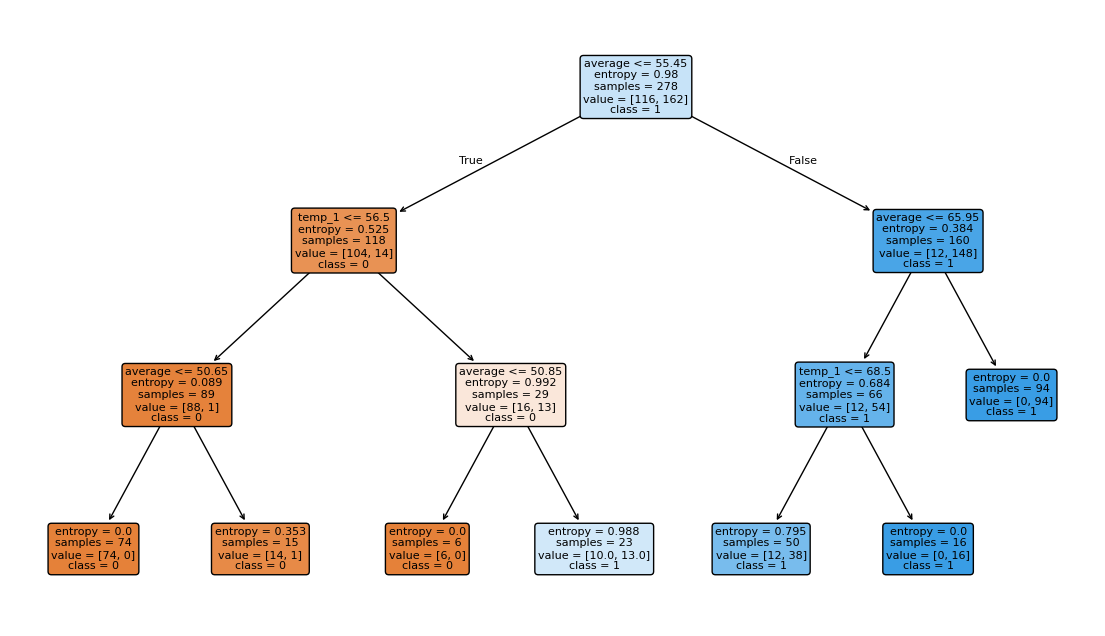

In [149]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# X
X = df[["temp_1", "average"]]

# y: clasificación binaria
# 1 si actual > 59, 0 si no
y = (df["actual"] > 59).astype(int)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# árbol
tree_clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

tree_clf.fit(X_train, y_train)

# plot
plt.figure(figsize=(14, 8))

plot_tree(
    tree_clf,
    feature_names=["temp_1", "average"],
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

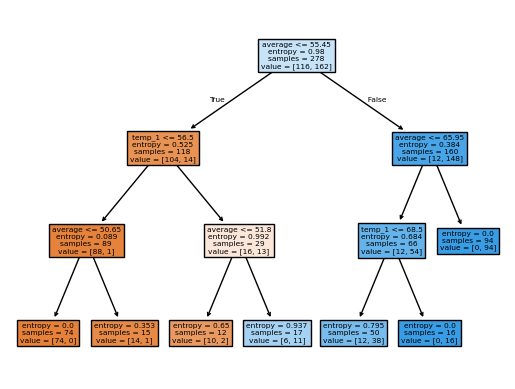

### 13. Construye un nuevo modelo `RandomForestClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC. ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [150]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_clf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_rf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(grid_rf.best_score_)
print(grid_rf.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
0.9174025974025973
{'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 10, 'n_estimators': 150}


In [151]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("accuracy_score", accuracy_score(y_test, y_pred))
print("precision_score", precision_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("roc_auc_score", roc_auc_score(y_test, y_proba))
print("confusion_matrix")
print(confusion_matrix(y_test, y_pred))

accuracy_score 0.9142857142857143
precision_score 0.8913043478260869
recall_score 0.9761904761904762
f1_score 0.9318181818181818
roc_auc_score 0.983843537414966
confusion_matrix
[[23  5]
 [ 1 41]]


Fitting 5 folds for each of 144 candidates, totalling 720 fits
RandomForestClassifier(criterion='entropy', max_depth=np.int64(4),
                       min_samples_leaf=10)
0.9246103896103897
{'criterion': 'entropy', 'max_depth': np.int64(4), 'min_samples_leaf': 10, 'n_estimators': 100}


accuracy_score 0.9428571428571428
precision_score 0.9318181818181818
recall_score 0.9761904761904762
f1_score 0.9534883720930233
roc_auc_score 0.9345238095238096
confusion_matrix
 [[25  3]
 [ 1 41]]


In [152]:
best_rf.predict_proba(X_test[:1])

array([[0.03039955, 0.96960045]])

In [153]:
best_rf.predict_proba(X_test[:1])[0]

array([0.03039955, 0.96960045])

c:\Users\Alberto Romero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.55503652, 0.44496348]])

array([0.5096769, 0.4903231])